
=== RESULTADOS DE BÚSQUEDA ===
     lr  epoch  wordNgrams  dim  accuracy  f1_macro       time
23  0.5     20           2  100  0.784946  0.784973  17.528551
22  0.5     20           2   50  0.782258  0.781898   9.951830
17  0.5     10           1  100  0.776882  0.777427   3.295690
16  0.5     10           1   50  0.776882  0.776769   2.896298
12  0.3     20           1   50  0.774194  0.774635   5.167099

🏆 Mejor combinación: {'lr': 0.5, 'epoch': 20.0, 'wordNgrams': 2.0, 'dim': 100.0, 'accuracy': 0.7849462365591398, 'f1_macro': 0.7849734855574271, 'time': 17.52855110168457}


Número de clases: 5
Train: 1738 | Val: 372 | Test: 373
Tiempo de entrenamiento: 16.10 s

=== HIPERPARÁMETROS DEL MODELO ===
lr: 0.5
epoch: 20
wordNgrams: 2
dim: 100
loss: softmax
minCount: 2
seed: 42

=== MÉTRICAS EN TEST ===
Accuracy: 0.6971 | F1-macro: 0.6905

=== CLASSIFICATION REPORT ===
                                    precision    recall  f1-score   support

          creatividad_y_producci_n       0.69      0.63      0.66        63
               negocios_y_finanzas       0.77      0.66      0.71        88
            otros_y_especializados       0.62      0.56      0.59        71
servicios_profesionales_y_p_blicos       0.73      0.82      0.77        84
              tecnolog_a_y_ciencia       0.65      0.79      0.72        67

                          accuracy                           0.70       373
                         macro avg       0.69      0.69      0.69       373
                      weighted avg       0.70      0.70      0.69       373


=== MÉTRICAS POR CL

,precision,recall,f1-score
creatividad_y_producci_n,0.689655,0.634921,0.661157
negocios_y_finanzas,0.773333,0.659091,0.711656
otros_y_especializados,0.625000,0.563380,0.592593
servicios_profesionales_y_p_blicos,0.726316,0.821429,0.770950
tecnolog_a_y_ciencia,0.654321,0.791045,0.716216


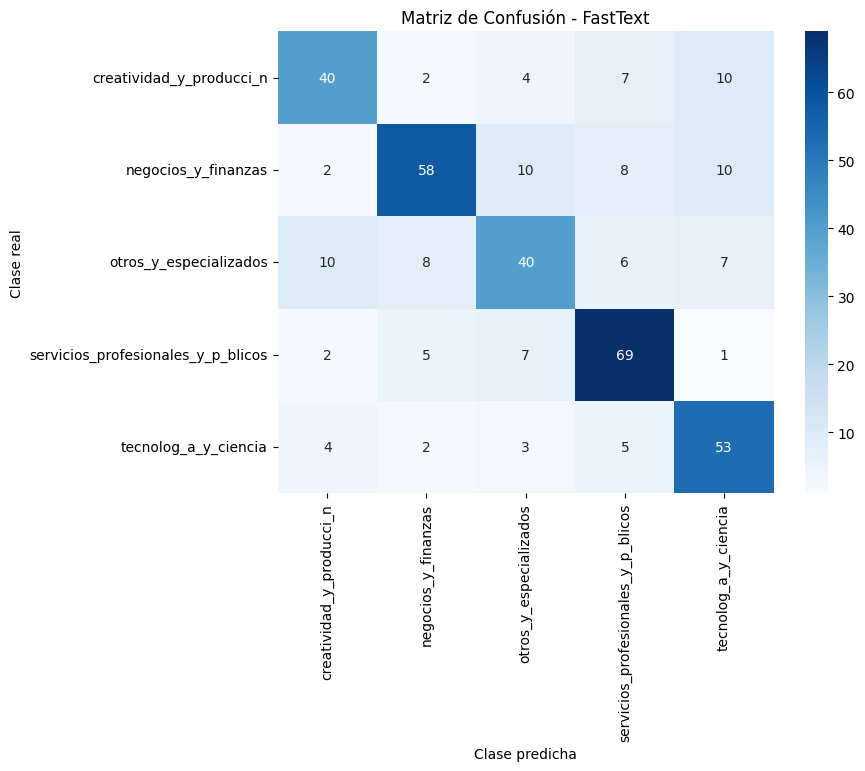


=== COMPARACIÓN REALES VS PREDICHAS (primeras 10 muestras) ===


,Real,Pred
0,otros_y_especializados,creatividad_y_producci_n
1,servicios_profesionales_y_p_blicos,otros_y_especializados
2,creatividad_y_producci_n,creatividad_y_producci_n
3,creatividad_y_producci_n,creatividad_y_producci_n
4,negocios_y_finanzas,negocios_y_finanzas
5,tecnolog_a_y_ciencia,tecnolog_a_y_ciencia
6,otros_y_especializados,otros_y_especializados
7,creatividad_y_producci_n,otros_y_especializados
8,otros_y_especializados,servicios_profesionales_y_p_blicos
9,tecnolog_a_y_ciencia,tecnolog_a_y_ciencia


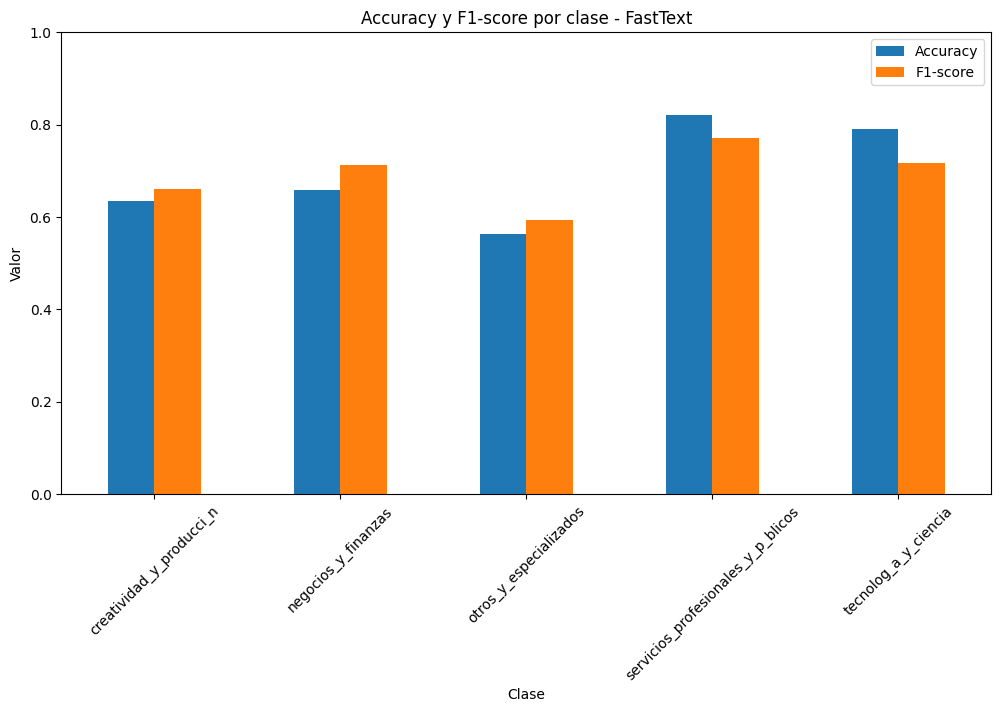


=== DISTRIBUCIÓN DE CLASES POR DIVISIÓN ===


,Train,Val,Test
Category,,,
negocios_y_finanzas,410,87,88
servicios_profesionales_y_p_blicos,389,83,84
otros_y_especializados,330,71,71
tecnolog_a_y_ciencia,316,68,67
creatividad_y_producci_n,293,63,63



=== EJEMPLOS DE LÍNEAS TRAIN.TXT ===
__label__creatividad_y_producci_n project construction manager professional summary motivated construction manager highly effective finding best method possible complete exceptional construction project strong knowledge civil engineering principle concept construction manager number year leading team general contractor laborer large scale residential commercial construction project skill excellent customer relation subcontractor management knowledgeable construction safety fluent arabic english work history project construction manager current company name city reviewed plan spec schematic design pre construction coordinated utility service provider according project schedule conducted weekly production operation contractor meeting facilitated stronger communication ability resolve critical issue performed regular job site observation provide direction general contractor personnel reported vice president production conformance contract schedule con

In [5]:
import os, time, joblib, re
import numpy as np
import pandas as pd
import fasttext
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt

# ======================================================
# CONFIGURACIÓN INICIAL
# ======================================================
SEED = 42
np.random.seed(SEED)

# ------------------------------------------------------
# 1. CARGA Y LIMPIEZA DE DATOS
# ------------------------------------------------------
df = pd.read_csv(
    "https://raw.githubusercontent.com/Darally06/NLP-Jarvis-Hiring/refs/heads/main/Data/Clean_words.csv"
)
df = df.rename(columns={'macro_label': 'Category'})

# --- Limpieza de texto ---
def limpiar_texto(txt):
    txt = str(txt).lower().strip()
    txt = re.sub(r"[^a-záéíóúñü0-9 ]+", " ", txt)
    return re.sub(r"\s+", " ", txt)

# --- Limpieza de etiquetas ---
def limpiar_label(lbl):
    lbl = str(lbl).strip().lower()
    lbl = re.sub(r"[^a-z0-9]+", "_", lbl)  # evita espacios o tildes
    return lbl

df["fasttext_text"] = df["clean_text"].apply(limpiar_texto)
df["Category"] = df["Category"].apply(limpiar_label)

# ------------------------------------------------------
# 2. ENCODIFICAR ETIQUETAS
# ------------------------------------------------------
le = LabelEncoder()
df["label"] = le.fit_transform(df["Category"])
num_classes = len(le.classes_)
print(f"Número de clases: {num_classes}")

# ------------------------------------------------------
# 3. DIVISIÓN DE DATOS
# ------------------------------------------------------
train, temp = train_test_split(df, test_size=0.3, random_state=SEED, stratify=df["label"])
val, test = train_test_split(temp, test_size=0.5, random_state=SEED, stratify=temp["label"])
train, val, test = train.reset_index(drop=True), val.reset_index(drop=True), test.reset_index(drop=True)
print(f"Train: {len(train)} | Val: {len(val)} | Test: {len(test)}")

# ------------------------------------------------------
# 4. EXPORTAR ARCHIVOS PARA FASTTEXT
# ------------------------------------------------------
def to_fasttext_format(df, text_col="fasttext_text", label_col="Category"):
    return [f"__label__{df.iloc[i][label_col]} {df.iloc[i][text_col]}" for i in range(len(df))]

def exportar_fasttext_archivos(train, val, test, carpeta="data_fasttext"):
    os.makedirs(carpeta, exist_ok=True)
    with open(os.path.join(carpeta, "train.txt"), "w", encoding="utf-8") as f:
        f.write("\n".join(to_fasttext_format(train)))
    with open(os.path.join(carpeta, "val.txt"), "w", encoding="utf-8") as f:
        f.write("\n".join(to_fasttext_format(val)))
    with open(os.path.join(carpeta, "test.txt"), "w", encoding="utf-8") as f:
        f.write("\n".join(to_fasttext_format(test)))

exportar_fasttext_archivos(train, val, test)

# ------------------------------------------------------
# 5. ENTRENAMIENTO DEL MODELO FASTTEXT
# ------------------------------------------------------
params = {
    "lr": 0.5,
    "epoch": 20,
    "wordNgrams": 2,
    "dim": 100,
    "loss": "softmax",
    "minCount": 2,
    "seed": SEED
}

base_dir = "results/FastText"
os.makedirs(base_dir, exist_ok=True)
model_path = os.path.join(base_dir, "fasttext_model.bin")

start = time.time()
model = fasttext.train_supervised(
    input="data_fasttext/train.txt",
    **params,
    verbose=2
)
elapsed = time.time() - start
print(f"Tiempo de entrenamiento: {elapsed:.2f} s")
model.save_model(model_path)

# ------------------------------------------------------
# 6. EVALUACIÓN
# ------------------------------------------------------
def evaluate_fasttext(model, df, le, text_col="fasttext_text", split_name="test", base_dir="results/FastText"):
    preds, true = [], []

    for text, label in zip(df[text_col], df["Category"]):
        try:
            labels, _ = model.predict(str(text))
            pred = labels[0].replace("__label__", "")
        except Exception:
            pred = "UNKNOWN"
        preds.append(pred)
        true.append(label)

    # Filtrar etiquetas desconocidas
    preds = [p if p in le.classes_ else np.random.choice(le.classes_) for p in preds]

    y_true = le.transform(true)
    y_pred = le.transform(preds)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    report = classification_report(y_true, y_pred, target_names=le.classes_, output_dict=True, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    split_dir = os.path.join(base_dir, split_name)
    os.makedirs(split_dir, exist_ok=True)
    pd.DataFrame(report).transpose().to_csv(f"{split_dir}/report.csv")
    pd.DataFrame(cm).to_csv(f"{split_dir}/confusion_matrix.csv", index=False)
    with open(f"{split_dir}/metrics.txt", "w") as f:
        f.write(f"Accuracy: {acc:.4f}\nF1-macro: {f1:.4f}\n")
        f.write(pd.DataFrame(report).transpose().to_string())

    return y_true, y_pred, acc, f1, report, cm

# Evaluar modelo
y_true, y_pred, test_acc, test_f1, test_report, test_cm = evaluate_fasttext(
    model, test, le, text_col="fasttext_text", split_name="test", base_dir=base_dir
)

# ------------------------------------------------------
# 7. RESULTADOS Y VISUALIZACIÓN
# ------------------------------------------------------
print("\n=== HIPERPARÁMETROS DEL MODELO ===")
for k, v in params.items():
    print(f"{k}: {v}")

print(f"\n=== MÉTRICAS EN TEST ===\nAccuracy: {test_acc:.4f} | F1-macro: {test_f1:.4f}")
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_true, y_pred, target_names=le.classes_, zero_division=0))

# ---- Métricas por clase ----
metrics_df = pd.DataFrame(test_report).transpose()
print("\n=== MÉTRICAS POR CLASE ===")
display(metrics_df.iloc[:-3][["precision", "recall", "f1-score"]])

# ---- Matriz de confusión ----
plt.figure(figsize=(8,6))
sns.heatmap(test_cm, annot=True, fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues")
plt.ylabel("Clase real")
plt.xlabel("Clase predicha")
plt.title("Matriz de Confusión - FastText")
plt.show()

# ---- Comparación reales vs predichas ----
comparison_df = pd.DataFrame({
    "Real": [le.classes_[i] for i in y_true],
    "Pred": [le.classes_[i] for i in y_pred]
})
print("\n=== COMPARACIÓN REALES VS PREDICHAS (primeras 10 muestras) ===")
display(comparison_df.head(10))

# ---- Gráfico de métricas por clase ----
per_class_f1 = [test_report[label]['f1-score'] for label in le.classes_]
per_class_acc = [np.mean(np.array(y_pred)[np.array(y_true)==i] == i) for i, _ in enumerate(le.classes_)]

metrics_plot_df = pd.DataFrame({
    "Clase": le.classes_,
    "Accuracy": per_class_acc,
    "F1-score": per_class_f1
})
metrics_plot_df.set_index("Clase", inplace=True)
metrics_plot_df.plot(kind="bar", figsize=(12,6))
plt.title("Accuracy y F1-score por clase - FastText")
plt.ylabel("Valor")
plt.ylim(0,1)
plt.xticks(rotation=45)
plt.show()

# ---- Distribución de clases ----
def resumen_clases(df, nombre):
    return pd.Series(df["Category"]).value_counts().rename(nombre)

resumen = pd.concat([
    resumen_clases(train, "Train"),
    resumen_clases(val, "Val"),
    resumen_clases(test, "Test")
], axis=1).fillna(0).astype(int)

print("\n=== DISTRIBUCIÓN DE CLASES POR DIVISIÓN ===")
display(resumen)

# Mostrar primeras líneas del archivo FastText
print("\n=== EJEMPLOS DE LÍNEAS TRAIN.TXT ===")
with open("data_fasttext/train.txt", encoding="utf-8") as f:
    for i in range(5):
        print(f.readline().strip())


In [3]:
import os, time, joblib, re
import numpy as np
import pandas as pd
import fasttext
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt

# ======================================================
# CONFIGURACIÓN INICIAL
# ======================================================
SEED = 42
np.random.seed(SEED)

df = pd.read_csv("https://raw.githubusercontent.com/Darally06/NLP-Jarvis-Hiring/refs/heads/main/Data/Clean_words.csv")
df = df.rename(columns={"macro_label": "Category"})


# --- Limpieza de texto ---
def limpiar_texto(txt):
    txt = str(txt).lower().strip()
    txt = re.sub(r"[^a-záéíóúñü0-9 ]+", " ", txt)
    return re.sub(r"\s+", " ", txt)

# --- Limpieza de etiquetas ---
def limpiar_label(lbl):
    lbl = str(lbl).strip().lower()
    lbl = re.sub(r"[^a-z0-9]+", "_", lbl)  # evita espacios o tildes
    return lbl

df["fasttext_text"] = df["clean_text"].apply(limpiar_texto)
df["Category"] = df["Category"].apply(limpiar_label)

df["label"] = LabelEncoder().fit_transform(df["Category"])

train, temp = train_test_split(df, test_size=0.3, stratify=df["label"], random_state=SEED)
val, test = train_test_split(temp, test_size=0.5, stratify=temp["label"], random_state=SEED)

def to_fasttext_format(df):
    return [f"__label__{row['Category']} {row['fasttext_text']}" for _, row in df.iterrows()]

os.makedirs("data_ft", exist_ok=True)
for name, data in [("train", train), ("val", val), ("test", test)]:
    with open(f"data_ft/{name}.txt", "w", encoding="utf-8") as f:
        f.write("\n".join(to_fasttext_format(data)))
# ======================================================
# 2️⃣ Búsqueda de hiperparámetros
# ======================================================
param_grid = {
    "lr": [0.1, 0.3, 0.5],
    "epoch": [10, 20],
    "wordNgrams": [1, 2],
    "dim": [50, 100]
}

resultados = []

for lr in param_grid["lr"]:
    for epoch in param_grid["epoch"]:
        for wordNgrams in param_grid["wordNgrams"]:
            for dim in param_grid["dim"]:
                params = {
                    "lr": lr, "epoch": epoch, "wordNgrams": wordNgrams,
                    "dim": dim, "minCount": 2, "loss": "softmax", "seed": SEED
                }

                print(f"\n🔹 Entrenando con: {params}")
                start = time.time()
                model = fasttext.train_supervised(input="data_ft/train.txt", **params, verbose=0)
                elapsed = time.time() - start

                # Evaluar en validación
                preds, y_true = [], []
                for text, label in zip(val["fasttext_text"], val["Category"]):
                    pred = model.predict(text)[0][0].replace("__label__", "")
                    preds.append(pred)
                    y_true.append(label)

                acc = accuracy_score(y_true, preds)
                f1 = f1_score(y_true, preds, average="macro")

                resultados.append({
                    "lr": lr, "epoch": epoch, "wordNgrams": wordNgrams,
                    "dim": dim, "accuracy": acc, "f1_macro": f1, "time": elapsed
                })

res_df = pd.DataFrame(resultados).sort_values("f1_macro", ascending=False)
print("\n=== RESULTADOS DE BÚSQUEDA ===")
print(res_df.head())

# ======================================================
# 3️⃣ Entrenar y evaluar el mejor modelo en test
# ======================================================
best_params = res_df.iloc[0].to_dict()
print(f"\n🏆 Mejor combinación: {best_params}")

final_model = fasttext.train_supervised(
    input="data_ft/train.txt",
    lr=best_params["lr"],
    epoch=int(best_params["epoch"]),
    wordNgrams=int(best_params["wordNgrams"]),
    dim=int(best_params["dim"]),
    minCount=2,
    loss="softmax",
    seed=SEED,
    verbose=2
)

# Evaluar en test
preds, y_true = [], []
for text, label in zip(test["fasttext_text"], test["Category"]):
    pred = final_model.predict(text)[0][0].replace("__label__", "")
    preds.append(pred)
    y_true.append(label)

test_acc = accuracy_score(y_true, preds)
test_f1 = f1_score(y_true, preds, average="macro")
print(f"\n=== RESULTADOS EN TEST ===\nAccuracy: {test_acc:.4f} | F1-macro: {test_f1:.4f}")

# Reporte detallado
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_true, preds))


🔹 Entrenando con: {'lr': 0.1, 'epoch': 10, 'wordNgrams': 1, 'dim': 50, 'minCount': 2, 'loss': 'softmax', 'seed': 42}

🔹 Entrenando con: {'lr': 0.1, 'epoch': 10, 'wordNgrams': 1, 'dim': 100, 'minCount': 2, 'loss': 'softmax', 'seed': 42}

🔹 Entrenando con: {'lr': 0.1, 'epoch': 10, 'wordNgrams': 2, 'dim': 50, 'minCount': 2, 'loss': 'softmax', 'seed': 42}

🔹 Entrenando con: {'lr': 0.1, 'epoch': 10, 'wordNgrams': 2, 'dim': 100, 'minCount': 2, 'loss': 'softmax', 'seed': 42}

🔹 Entrenando con: {'lr': 0.1, 'epoch': 20, 'wordNgrams': 1, 'dim': 50, 'minCount': 2, 'loss': 'softmax', 'seed': 42}

🔹 Entrenando con: {'lr': 0.1, 'epoch': 20, 'wordNgrams': 1, 'dim': 100, 'minCount': 2, 'loss': 'softmax', 'seed': 42}

🔹 Entrenando con: {'lr': 0.1, 'epoch': 20, 'wordNgrams': 2, 'dim': 50, 'minCount': 2, 'loss': 'softmax', 'seed': 42}

🔹 Entrenando con: {'lr': 0.1, 'epoch': 20, 'wordNgrams': 2, 'dim': 100, 'minCount': 2, 'loss': 'softmax', 'seed': 42}

🔹 Entrenando con: {'lr': 0.3, 'epoch': 10, 'wordNgr